In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [7]:
## -- load in transmission spectra
# logarithmic limb darkening:
wavesR50, wavehwsR50, depthsR50, deptherrsR50 = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_logLD_R50.txt', skiprows=1, unpack=True)
depthsR50 *= 1.e6
deptherrsR50 *= 1.e6
# quadratic limb darkening:
void, void, depthsR50_quad, deptherrsR50_quad = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_quadLD_R50.txt', skiprows=1, unpack=True)
depthsR50_quad *= 1.e6
deptherrsR50_quad *= 1.e6
# 4-term non-linear limb darkening:
wavesR50, wavehwsR50, depthsR50_4term, deptherrsR50_4term = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_4termLD_R50.txt', skiprows=1, unpack=True)
depthsR50_4term *= 1.e6
deptherrsR50_4term *= 1.e6

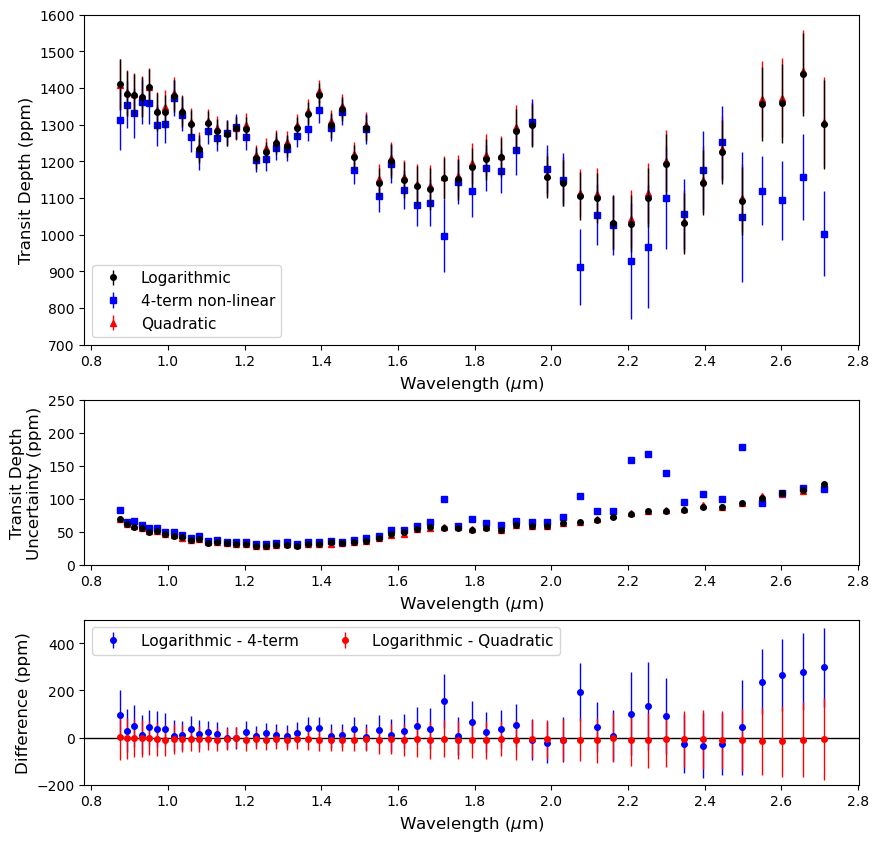

In [13]:
fig, ax = plt.subplots(figsize=(10,10), nrows=3, gridspec_kw={'height_ratios':[2,1,1]})
plt.subplots_adjust(hspace=0.25)
ax[0].errorbar(wavesR50, depthsR50, deptherrsR50, c='black', lw=1, ls='None', zorder=5, marker='o', ms=4, label='Logarithmic')
ax[0].errorbar(wavesR50, depthsR50_4term, deptherrsR50_4term, c='blue', lw=1, ls='None', zorder=4, marker='s', ms=4, label='4-term non-linear')
ax[0].errorbar(wavesR50, depthsR50_quad, deptherrsR50_quad, c='red', lw=1, ls='None', zorder=3, marker='^', ms=4, label='Quadratic')
ax[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[0].set_ylabel(r'Transit Depth (ppm)', fontsize=12)
ax[0].legend(loc='lower left', fontsize=11, ncol=1)
ax[0].set_ylim(700,1600)
ax[0].xaxis.set_major_locator(MultipleLocator(0.2))

ax[1].plot(wavesR50, deptherrsR50, c='black', lw=1, ls='None', zorder=5, marker='o', ms=4, label='Logarithmic')
ax[1].plot(wavesR50, deptherrsR50_4term, c='blue', lw=1, ls='None', zorder=4, marker='s', ms=4, label='4-term non-linear')
ax[1].plot(wavesR50, deptherrsR50_quad, c='red', lw=1, ls='None', zorder=3, marker='^', ms=4, label='Quadratic')
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylabel('Transit Depth\n'+'Uncertainty (ppm)', fontsize=12)
ax[1].set_ylim(0,250)
ax[1].xaxis.set_major_locator(MultipleLocator(0.2))

ax[2].axhline(0., c='black', lw=1)
ax[2].errorbar(wavesR50, depthsR50-depthsR50_4term, np.sqrt((deptherrsR50**2)+(deptherrsR50_4term**2)), c='blue', lw=1, ls='None', zorder=5, marker='o', ms=4, label='Logarithmic - 4-term')
ax[2].errorbar(wavesR50, depthsR50-depthsR50_quad, np.sqrt((deptherrsR50**2)+(deptherrsR50_quad**2)), c='red', lw=1, ls='None', zorder=5, marker='o', ms=4, label='Logarithmic - Quadratic')
ax[2].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[2].set_ylabel(r'Difference (ppm)', fontsize=12)
ax[2].legend(loc='upper left', fontsize=11, ncol=2)
ax[2].set_ylim(-200,500)
ax[2].xaxis.set_major_locator(MultipleLocator(0.2))
plt.savefig('./figures/Figure10.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure10.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()